https://www.bilibili.com/video/BV1LEB8BTE4G/?spm_id_from=333.337.search-card.all.click&vd_source=8c7abd9bc14823124fe665c92c1f2ddd


交叉熵：用于评估模型输出的概率分布与真实概率分布的差异
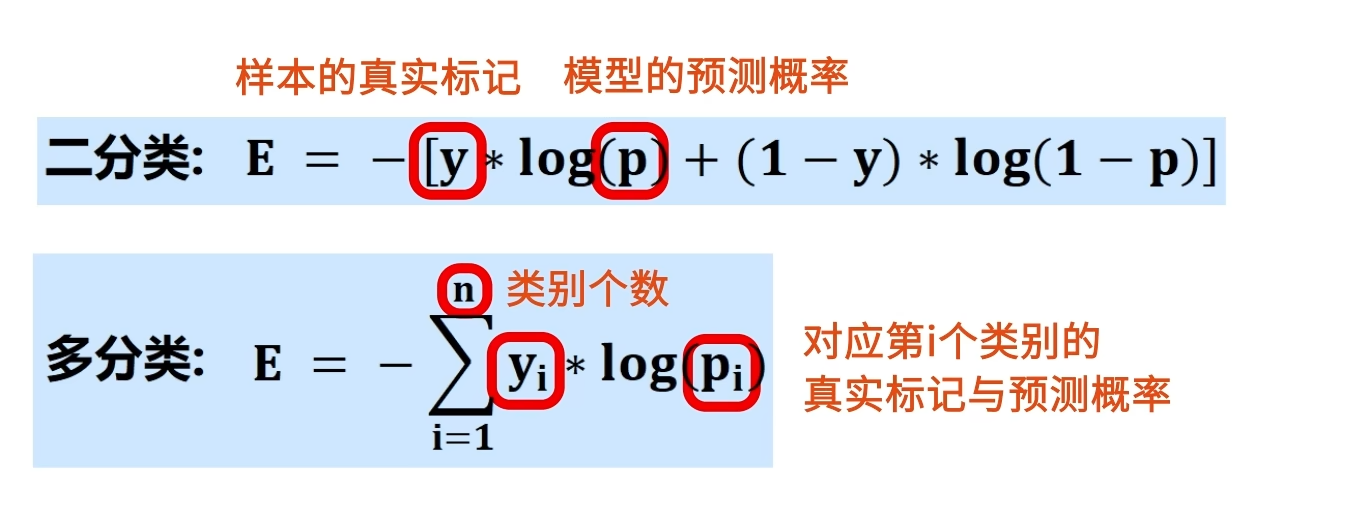


In [ ]:
import torch

## 逻辑回归输出之前往往还需要softmax
def softmax(x):
    max_x = torch.max(x,dim=-1,keepdims=True)[0]
    ex_fenzi = torch.exp(x-max_x)
    ex_fenmu = torch.sum(ex_fenzi,dim=-1,keepdims=True)
    return ex_fenzi/ex_fenmu

def cross_entropy(logits,labels): ##输入认为是逻辑回归的输出以及真实标签  这里的labels是样本中正确标签的索引，多样本
    probs = softmax(logits)

    one_shot= torch.zeros_like(probs)
    rows = torch.arange(len(labels)) #得到样本数量
    one_shot[rows,labels] = 1.0  #并把对应样本数量的正确标签位置设为1，其他都是0

    log_probs = torch.log(probs)
    cross_entropy_out = - torch.sum(one_shot*logits)/len(probs) 
    return cross_entropy_out


In [12]:
logits = torch.randn(3,5) # 随机一个3行5列的二维数组 表示有三个样本 五个类别
labels = torch.tensor([2,4,0]) #表示样本0的真实标签是2 样本1的真实标签是4 样本2的真实标签是0
cross_entropy(logits,labels)


tensor(-0.0725)